<a href="https://colab.research.google.com/github/23170102/Pronostico_Bitcoin/blob/main/Pronostico_Bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. CARGANDO Y PREPARANDO DATASET (VERSIÓN BLINDADA)
[+] Dataset cargado y limpio con 20000 registros.


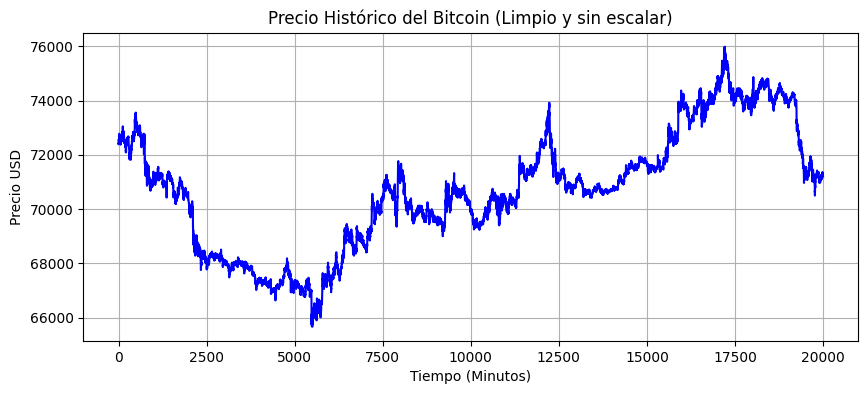

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("==================================================")
print("1. CARGANDO Y PREPARANDO DATASET (VERSIÓN BLINDADA)")
print("==================================================")

ruta_archivo = 'https://raw.githubusercontent.com/23170102/Pronostico_Bitcoin/refs/heads/main/bitcoin_ligero.csv'
df = pd.read_csv(ruta_archivo)

# ---> LA CURA DEFINITIVA CONTRA EL NaN <---
# Si falta un precio, copiamos el del minuto anterior (Forward Fill)
df['Close'] = df['Close'].ffill()
# Por si el primerísimo renglón estaba vacío, copiamos el de abajo (Backward Fill)
df['Close'] = df['Close'].bfill()
# ------------------------------------------

df = df.tail(20000).reset_index(drop=True)

datos_precio = df.filter(['Close']).values

escalador = MinMaxScaler(feature_range=(0, 1))
datos_escalados = escalador.fit_transform(datos_precio)

pasos_historia = 120
pasos_futuro = 3

x_entrenamiento = []
y_entrenamiento = []

for i in range(pasos_historia, len(datos_escalados) - pasos_futuro + 1):
    x_entrenamiento.append(datos_escalados[i - pasos_historia : i, 0])
    y_entrenamiento.append(datos_escalados[i : i + pasos_futuro, 0])

x_entrenamiento, y_entrenamiento = np.array(x_entrenamiento), np.array(y_entrenamiento)
x_entrenamiento = np.reshape(x_entrenamiento, (x_entrenamiento.shape[0], x_entrenamiento.shape[1], 1))

print(f"[+] Dataset cargado y limpio con {len(df)} registros.")

# Mostrar una gráfica rápida de cómo se ve el precio histórico ya limpio
plt.figure(figsize=(10,4))
plt.plot(df['Close'], color='blue')
plt.title('Precio Histórico del Bitcoin (Limpio y sin escalar)')
plt.xlabel('Tiempo (Minutos)')
plt.ylabel('Precio USD')
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("==================================================")
print("2. CONSTRUYENDO Y ENTRENANDO LA RED LSTM MEJORADA")
print("==================================================")

# 1. Separar en Entrenamiento (80%) y Prueba (20%)
limite = int(len(x_entrenamiento) * 0.8)

x_train, x_test = x_entrenamiento[:limite], x_entrenamiento[limite:]
y_train, y_test = y_entrenamiento[:limite], y_entrenamiento[limite:]

# 2. Construir la Arquitectura de la LSTM (Mucho más profunda)
modelo = Sequential()

# Primera capa LSTM: Aumentamos unidades a 100
modelo.add(LSTM(units=100, return_sequences=True, input_shape=(x_train.shape[1], 1)))
modelo.add(Dropout(0.2))

# Segunda capa LSTM: Agregamos otra capa intermedia
modelo.add(LSTM(units=100, return_sequences=True))
modelo.add(Dropout(0.2))

# Tercera capa LSTM
modelo.add(LSTM(units=100, return_sequences=False))
modelo.add(Dropout(0.2))

# Capa de salida: Sigue siendo de 3 pasos (minutos)
modelo.add(Dense(units=pasos_futuro))

# 3. Compilar usando el Error Cuadrático Medio (MSE)
modelo.compile(optimizer='adam', loss='mean_squared_error')

print("--- INICIANDO ENTRENAMIENTO MEJORADO (Tardará más) ---")
# Aumentamos epochs de 5 a 50
historial = modelo.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test))
print("[+] ¡Entrenamiento Finalizado!")

2. CONSTRUYENDO Y ENTRENANDO LA RED LSTM MEJORADA
--- INICIANDO ENTRENAMIENTO MEJORADO (Tardará más) ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0051 - val_loss: nan
Epoch 2/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0019 - val_loss: nan
Epoch 3/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0015 - val_loss: nan
Epoch 4/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0012 - val_loss: nan
Epoch 5/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 9.9415e-04 - val_loss: nan
Epoch 6/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 7.8474e-04 - val_loss: nan
Epoch 7/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 7.1040e-04 - val_loss: nan
Epoch 8/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 5.9350e-04 - val_loss: nan
Epoch 9/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 5.4393e-04 - val_loss: nan
Epoch 10/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 4.9289e-04 - val_loss: nan
Epoch 11/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 4.5366e-04 - val_loss: nan
Epoch 12/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - 

In [ ]:
# Guardar el cerebro ya entrenado en un archivo
modelo.save('modelo_bitcoin_entrenado.keras')
print("¡Modelo guardado exitosamente!")

¡Modelo guardado exitosamente!


In [3]:
from tensorflow.keras.models import load_model
modelo = load_model('modelo_bitcoin_entrenado.keras')
print("Modelo pre-entrenado cargado al instante.")

Modelo pre-entrenado cargado al instante.


3. EVALUACIÓN Y GRÁFICA DE PRONÓSTICO (Líneas Roja y Verde)
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

--- RESULTADOS DEL MODELO (CALIFICACIONES) ---
MSE  : 6407.68
RMSE : $80.05 USD (En promedio, la IA se equivocó por esta cantidad)
R^2  : 0.9949 (Calificación de exactitud. 1.0 es perfecto)



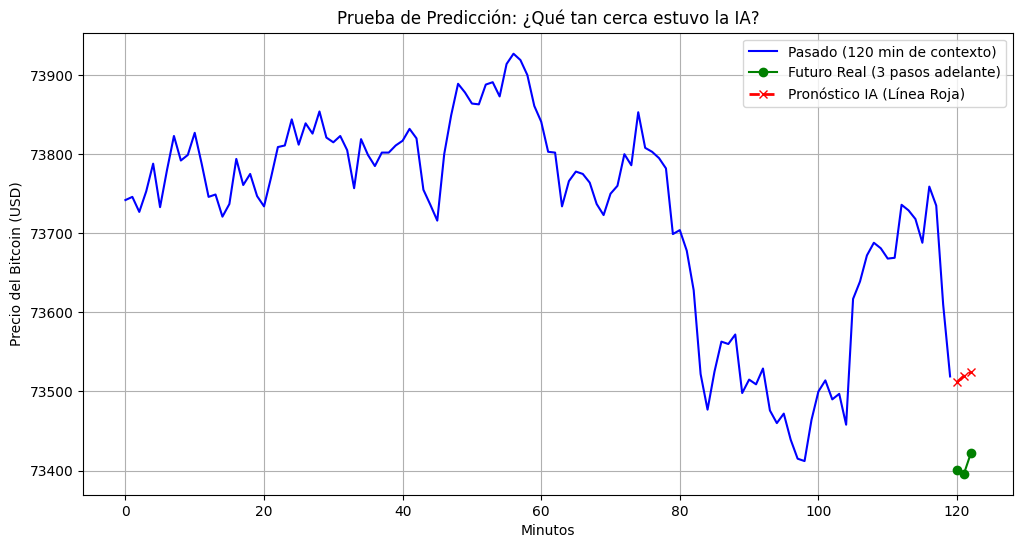

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

print("==================================================")
print("3. EVALUACIÓN Y GRÁFICA DE PRONÓSTICO (Líneas Roja y Verde)")
print("==================================================")

# ---> ¡LA PIEZA FALTANTE (Preparar el Examen)! <---
# Separamos el 20% final de los datos para poner a prueba a la IA
limite = int(len(x_entrenamiento) * 0.8)
x_test = x_entrenamiento[limite:]
y_test = y_entrenamiento[limite:]
# --------------------------------------------------

# 1. Hacemos las predicciones con el 20% de datos que la IA NO conoce (el examen)
predicciones_escaladas = modelo.predict(x_test)

# 2. Revertimos la escala (Regresamos los datos de 0-1 a Dólares reales)
predicciones_usd = escalador.inverse_transform(predicciones_escaladas)
y_test_usd = escalador.inverse_transform(y_test)

# ==========================================
# CÁLCULO DE MÉTRICAS
# ==========================================
mse = mean_squared_error(y_test_usd, predicciones_usd)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_usd, predicciones_usd)

print(f"\n--- RESULTADOS DEL MODELO (CALIFICACIONES) ---")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : ${rmse:.2f} USD (En promedio, la IA se equivocó por esta cantidad)")
print(f"R^2  : {r2:.4f} (Calificación de exactitud. 1.0 es perfecto)\n")

# ==========================================
# LA GRÁFICA: HISTORIA vs REALIDAD vs PRONÓSTICO
# ==========================================
# Elegimos un momento al azar del examen para graficar (puedes cambiar este número después)
ejemplo = 150

# Extraemos la historia (los 120 minutos previos) y la regresamos a dólares
historia_usd = escalador.inverse_transform(x_test[ejemplo].reshape(-1, 1))

# Extraemos los 3 minutos futuros: Lo que pasó en realidad vs Lo que dijo la IA
real_usd = y_test_usd[ejemplo]
predicho_usd = predicciones_usd[ejemplo]

# Preparamos el eje X (El tiempo en minutos)
tiempo_historia = np.arange(0, pasos_historia)
tiempo_futuro = np.arange(pasos_historia, pasos_historia + pasos_futuro)

plt.figure(figsize=(12, 6))

# Graficamos los 120 minutos de contexto (Azul)
plt.plot(tiempo_historia, historia_usd, color='blue', label='Pasado (120 min de contexto)')

# Graficamos lo que REALMENTE pasó en los 3 minutos siguientes (Verde)
plt.plot(tiempo_futuro, real_usd, color='green', marker='o', label='Futuro Real (3 pasos adelante)')

# Graficamos la PREDICCIÓN de la IA para esos mismos 3 minutos (Rojo)
plt.plot(tiempo_futuro, predicho_usd, color='red', marker='x', linestyle='dashed', linewidth=2, label='Pronóstico IA (Línea Roja)')

plt.title('Prueba de Predicción: ¿Qué tan cerca estuvo la IA?')
plt.xlabel('Minutos')
plt.ylabel('Precio del Bitcoin (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import pandas as pd

# 1. Leemos el archivo gigante
df_gigante = pd.read_csv('btcusd_1-min_data.csv')

# 2. Cortamos solo los últimos 20,000 renglones (los únicos que usas)
df_pequeno = df_gigante.tail(20000)

# 3. Guardamos esta versión ligera en un nuevo archivo
df_pequeno.to_csv('bitcoin_ligero.csv', index=False)

print("¡Archivo ligero creado con éxito!")

¡Archivo ligero creado con éxito!
